In [1]:
from torch import nn
import torch
import pandas as pd
import os
import re
import json
import matplotlib.pyplot as plt
import numpy as np
import gc
from master_thesis.deep_learning.data import ECGDataset
from master_thesis.deep_learning.models.ecg_model import ECGModel
from master_thesis.deep_learning.utils import load_config
from torch.utils.data import DataLoader
from tqdm import tqdm
from typing import Any
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    confusion_matrix,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

In [2]:
# loading all models for 5 seeds both for pretrained and finetuned models
checkpoint_dirs = os.listdir("../checkpoints")
bigru_pattern = re.compile(r"^bigru_fusion_(?:pretrain|finetune)_\d+$")
cnn_lstm_pattern = re.compile(r"^cnn_lstm_fusion_(?:pretrain|finetune)_\d+$")
matching_dirs = [
    d for d in checkpoint_dirs
    if bigru_pattern.match(d) or cnn_lstm_pattern.match(d)
]

In [3]:
matching_dirs

['bigru_fusion_finetune_123',
 'bigru_fusion_finetune_124',
 'bigru_fusion_finetune_125',
 'bigru_fusion_finetune_126',
 'bigru_fusion_finetune_127',
 'bigru_fusion_pretrain_123',
 'bigru_fusion_pretrain_124',
 'bigru_fusion_pretrain_125',
 'bigru_fusion_pretrain_126',
 'bigru_fusion_pretrain_127',
 'cnn_lstm_fusion_finetune_123',
 'cnn_lstm_fusion_finetune_124',
 'cnn_lstm_fusion_finetune_125',
 'cnn_lstm_fusion_finetune_126',
 'cnn_lstm_fusion_finetune_127',
 'cnn_lstm_fusion_pretrain_123',
 'cnn_lstm_fusion_pretrain_124',
 'cnn_lstm_fusion_pretrain_125',
 'cnn_lstm_fusion_pretrain_126',
 'cnn_lstm_fusion_pretrain_127']

In [4]:
models = {
    "model_type": [],
    "train_stage": [],
    "seed": [],
    "model_path": [],
    "train_loss": [],
    "val_loss": []
}
for dir_name in matching_dirs:
    model_type = "gru" if "bigru" in dir_name else "cnn_lstm"
    train_stage = "pretrain" if "pretrain" in dir_name else "finetune"
    seed = int(dir_name.split("_")[-1])
    model_path = f"../checkpoints/{dir_name}/best.pt"
    history = json.load(open(f"../checkpoints/{dir_name}/best_history.json"))
    train_loss = history["train_loss"]
    val_loss = history["val_loss"]
    models["model_type"].append(model_type)
    models["train_stage"].append(train_stage)
    models["seed"].append(seed)
    models["model_path"].append(model_path)
    models["train_loss"].append(train_loss)
    models["val_loss"].append(val_loss)

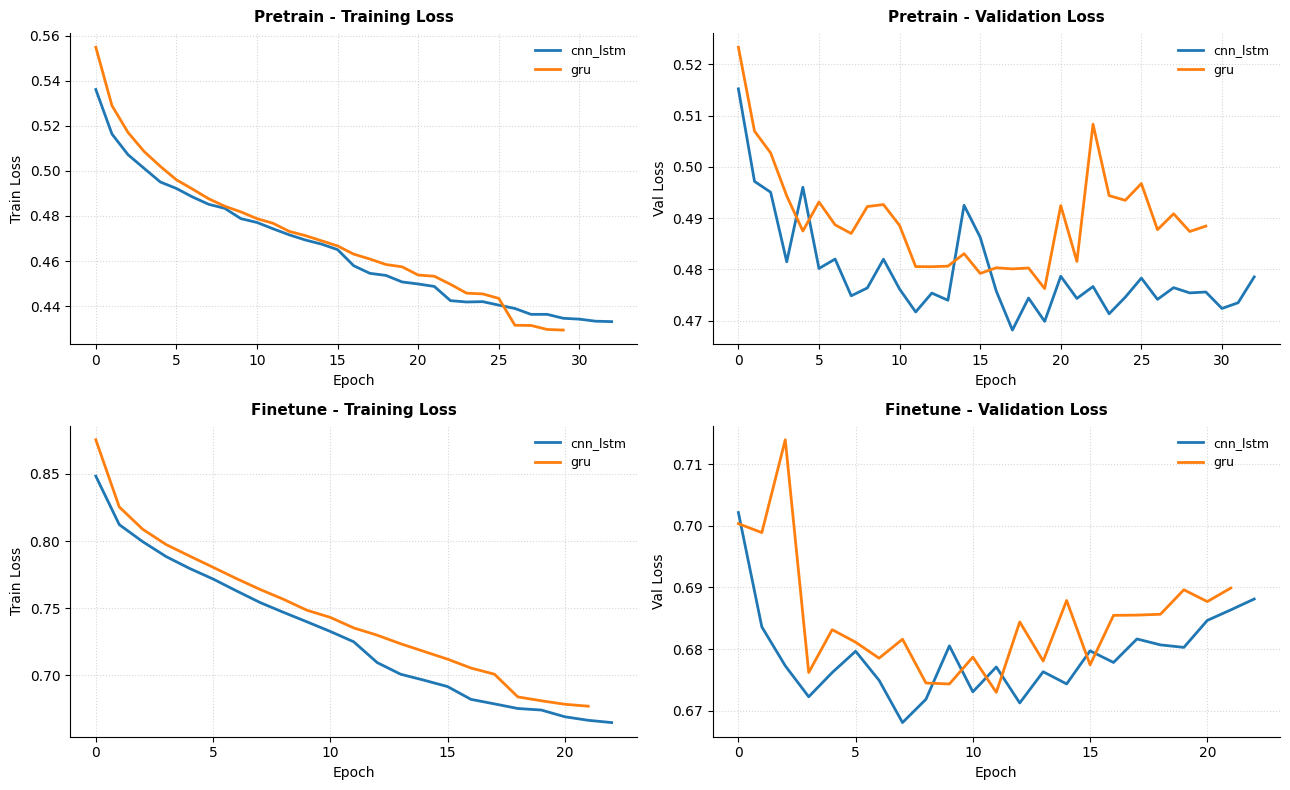

In [5]:
SELECTED_SEED = 123
stages = sorted(list(set(models["train_stage"])), key=lambda x: ["pretrain", "finetune"].index(x))
unique_models = sorted(list(set(models["model_type"])))

palette = {"model_A": "#2563EB", "model_B": "#E11D48"}

fig, axes = plt.subplots(
    nrows=len(stages), 
    ncols=2, 
    figsize=(13, 4 * len(stages)), 
    squeeze=False
)

for row_idx, stage in enumerate(stages):
    ax_train = axes[row_idx, 0]
    ax_val = axes[row_idx, 1]

    for model_idx, m_type in enumerate(unique_models):
        matches = [
            i
            for i in range(len(models["model_type"]))
            if models["model_type"][i] == m_type
            and models["seed"][i] == SELECTED_SEED
            and models["train_stage"][i] == stage
        ]

        if not matches:
            continue

        run_idx = matches[0]
        train_curve = np.asarray(models["train_loss"][run_idx], dtype=float)
        val_curve = np.asarray(models["val_loss"][run_idx], dtype=float)

        color = palette.get(m_type, f"C{model_idx}")

        ax_train.plot(
            np.arange(len(train_curve)),
            train_curve,
            label=m_type,
            color=color,
            linewidth=2.0,
        )

        ax_val.plot(
            np.arange(len(val_curve)),
            val_curve,
            label=m_type,
            color=color,
            linewidth=2.0,
        )

    stage_title = str(stage).replace("_", " ").title()
    ax_train.set_title(f"{stage_title} - Training Loss", fontsize=11, fontweight="bold", pad=8)
    ax_val.set_title(f"{stage_title} - Validation Loss", fontsize=11, fontweight="bold", pad=8)

    for ax, label in [(ax_train, "Train Loss"), (ax_val, "Val Loss")]:
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel(label, fontsize=10)
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles, labels, frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
def predict_single_model(
    model: nn.Module,
    loader: DataLoader,
    diseases: list[str],
    use_tabular: bool = False,
    return_logits: bool = False,
    device: torch.device | None = None,
) -> np.ndarray:
    """runs inference for a single model instance over a dataLoader"""
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    batch_outputs = []

    with torch.no_grad():
        for batch in loader:
            waveforms = batch["waveform"].to(device, non_blocking=True)
            tabular_data = batch.get("tabular")

            if tabular_data is not None and use_tabular:
                tabular_data = tabular_data.to(device, non_blocking=True)
            else:
                tabular_data = None

            out = model(waveforms, tabular_data)

            if isinstance(out, tuple):
                outputs_dict = out[0]
            elif isinstance(out, dict):
                outputs_dict = out
            else:
                batch_outputs.append(
                    out.cpu().numpy()
                    if return_logits
                    else torch.sigmoid(out).cpu().numpy()
                )
                continue

            logits = torch.stack(
                [outputs_dict[d].squeeze(-1) for d in diseases], dim=-1
            )
            vals = (
                logits if return_logits else torch.sigmoid(logits)
            ).detach().cpu().numpy()
            batch_outputs.append(vals)

    return np.concatenate(batch_outputs, axis=0)


def run_inference(
    dataset_args: dict,
    models: dict | None = None,
    instantiated_models: list[nn.Module] | None = None,
    config_map: dict | None = None,
    batch_size: int = 32,
    num_workers: int = 0,
    return_logits: bool = False,
    device: torch.device | None = None,
) -> dict[str, list[Any]]:
    """runs batch inference over a dataset split

    supports either:
      1. passing instantiated_models directly
      2. passing `models` dict containing checkpoint paths and metadata to load
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    pretrain_dataset = ECGDataset(**dataset_args, pretrain=True)
    pretrain_loader = DataLoader(
        pretrain_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    finetune_dataset = ECGDataset(**dataset_args, pretrain=False)
    finetune_loader = DataLoader(
        finetune_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    pretrain_diseases = list(pretrain_dataset.label_columns)
    finetune_diseases = [
        d
        for d in finetune_dataset.label_columns
        if d != "shd_moderate_or_greater_flag"
    ]

    split_name = dataset_args.get("split", "dataset")
    results = {
        "model_type": [],
        "train_stage": [],
        "seed": [],
        "predictions": [],
    }

    total_runs = len(models["model_path"]) if models is not None else len(instantiated_models)

    for i in tqdm(range(total_runs), desc=f"Predicting on '{split_name}' set"):
        model_type = models["model_type"][i]
        train_stage = models["train_stage"][i]
        seed = models["seed"][i]

        loader = pretrain_loader if train_stage == "pretrain" else finetune_loader
        diseases = pretrain_diseases if train_stage == "pretrain" else finetune_diseases

        config = config_map[(model_type, train_stage)]
        use_tabular = config.get("tabular", {}).get("enabled", False)

        if instantiated_models is not None:
            model = instantiated_models[i].to(device)
            owns_model = False
        else:
            model = ECGModel(diseases=diseases, config=config)
            checkpoint = torch.load(models["model_path"][i], map_location=device)
            state_dict = (
                checkpoint["model_state_dict"]
                if "model_state_dict" in checkpoint
                else checkpoint
            )
            model.load_state_dict(state_dict)
            model.to(device)
            owns_model = True

        preds = predict_single_model(
            model=model,
            loader=loader,
            diseases=diseases,
            use_tabular=use_tabular,
            return_logits=return_logits,
            device=device,
        )

        results["model_type"].append(model_type)
        results["train_stage"].append(train_stage)
        results["seed"].append(seed)
        results["predictions"].append(preds)

        if owns_model:
            del model, checkpoint, state_dict
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return results

In [ ]:
# the same configs because the only difference is the seed, which is not relevant for inference
bigru_pretrain_config = load_config("../configs/15_bigru_fusion_pretrain_123.yaml")
bigru_finetune_config = load_config("../configs/20_bigru_fusion_finetune_123.yaml")
cnn_lstm_pretrain_config = load_config(
    "../configs/25_cnn_lstm_fusion_pretrain_123.yaml"
)
cnn_lstm_finetune_config = load_config(
    "../configs/30_cnn_lstm_fusion_finetune_123.yaml"
)

CONFIG_MAP = {
    ("gru", "pretrain"): bigru_pretrain_config,
    ("gru", "finetune"): bigru_finetune_config,
    ("cnn_lstm", "pretrain"): cnn_lstm_pretrain_config,
    ("cnn_lstm", "finetune"): cnn_lstm_finetune_config,
}

common_tabular_features = [
    "sex",
    "ventricular_rate",
    "atrial_rate",
    "pr_interval",
    "qrs_duration",
    "qt_corrected",
    "age_at_ecg",
]

# validation
val_args = {
    "waveforms_path": "../data/EchoNext_val_waveforms.npy",
    "metadata_path": "../data/echonext_metadata_100k.csv",
    "split": "val",
    "tabular_path": "../data/EchoNext_val_tabular_features.npy",
    "tabular_features": common_tabular_features,
}
val_logits_dict = run_inference(
    dataset_args=val_args,
    models=models,
    config_map=CONFIG_MAP,
    return_logits=True,
)

# validation
val_args = {
    "waveforms_path": "../data/EchoNext_val_waveforms.npy",
    "metadata_path": "../data/echonext_metadata_100k.csv",
    "split": "val",
    "tabular_path": "../data/EchoNext_val_tabular_features.npy",
    "tabular_features": common_tabular_features,
}
val_logits_dict = run_inference(
    dataset_args=val_args,
    models=models,
    config_map=CONFIG_MAP,
    return_logits=True,
)

Predicting on 'val' set: 100%|██████████| 20/20 [00:40<00:00,  2.05s/it]


In [8]:
# test
test_args = {
    "waveforms_path": "../data/EchoNext_test_waveforms.npy",
    "metadata_path": "../data/echonext_metadata_100k.csv",
    "split": "test",
    "tabular_path": "../data/EchoNext_test_tabular_features.npy",
    "tabular_features": common_tabular_features,
}
test_logits_dict = run_inference(
    dataset_args=test_args,
    models=models,
    config_map=CONFIG_MAP,
    return_logits=True,
)

Predicting on 'test' set: 100%|██████████| 20/20 [00:47<00:00,  2.39s/it]


In [9]:
def plot_logits_calibration(y_true, logits, labels=None, model_name="Model", n_bins=10):
    y_true = np.asarray(y_true)
    logits = np.asarray(logits)
    probs = 1.0 / (1.0 + np.exp(-np.clip(logits, -50, 50)))

    is_multilabel = (logits.ndim == 2 and logits.shape[1] > 1)

    if is_multilabel:
        n_classes = logits.shape[1]
        if labels is None or isinstance(labels, str):
            labels = [f"Disease {i+1}" for i in range(n_classes)]

        n_cols = 4
        n_rows = int(np.ceil(n_classes / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), sharex=True, sharey=True)
        axes = np.array(axes).flatten()

        brier_scores = {}
        for i in range(n_classes):
            ax = axes[i]
            y_col = y_true[:, i]
            p_col = probs[:, i]

            if len(np.unique(y_col)) > 1:
                prob_true, prob_pred = calibration_curve(y_col, p_col, n_bins=n_bins, strategy='uniform')
                brier = brier_score_loss(y_col, p_col)
                brier_scores[labels[i]] = brier

                ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
                ax.plot(prob_pred, prob_true, marker='o', markersize=3, color='crimson')
                ax.set_title(f"{labels[i]}\n(Brier: {brier:.4f})", fontsize=9)
            else:
                ax.text(0.5, 0.5, 'No positive instances', ha='center', va='center', fontsize=8)
                ax.set_title(labels[i], fontsize=9)

            ax.grid(True, linestyle='--', alpha=0.3)
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])

        for j in range(n_classes, len(axes)):
            fig.delaxes(axes[j])

        fig.text(0.5, 0.02, 'Mean Predicted Probability', ha='center', fontsize=12)
        fig.text(0.01, 0.5, 'Fraction of Positives', va='center', rotation='vertical', fontsize=12)
        plt.suptitle(f'{model_name} - Disease Calibration Curves', fontsize=14, fontweight='bold')
        plt.tight_layout(rect=[0.02, 0.04, 1, 0.96])
        plt.show()

        return brier_scores

    else:
        y_true = y_true.squeeze()
        probs = probs.squeeze()
        label_title = labels if isinstance(labels, str) else "Composite Label"

        prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=n_bins, strategy='uniform')
        brier = brier_score_loss(y_true, probs)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

        ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
        ax1.plot(prob_pred, prob_true, marker='s', color='crimson', linewidth=2,
                 label=f'{label_title} (Brier: {brier:.4f})')
        ax1.set_ylabel('Fraction of Positives', fontsize=11)
        ax1.set_title(f'{model_name}\nCalibration: {label_title}', fontsize=13, fontweight='bold')
        ax1.legend(loc='lower right', fontsize=10)
        ax1.grid(True, linestyle='--', alpha=0.5)

        ax2.hist(probs, bins=n_bins, color='royalblue', edgecolor='black', alpha=0.7)
        ax2.set_xlabel('Predicted Probability', fontsize=11)
        ax2.set_ylabel('Count', fontsize=11)
        ax2.grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()

        return brier

In [10]:
# val split from metadata file
all_metadata = pd.read_csv("../data/echonext_metadata_100k.csv")
val_y_true = all_metadata[all_metadata["split"] == "val"].reset_index(drop=True)
test_y_true = all_metadata[all_metadata["split"] == "test"].reset_index(drop=True)

# filter only flag columns
val_y_true = val_y_true.filter(regex='_flag$')
test_y_true = test_y_true.filter(regex='_flag$')

In [11]:
# sanity check
val_y_true.columns, len(val_y_true.columns)

(Index(['lvef_lte_45_flag', 'lvwt_gte_13_flag',
        'aortic_stenosis_moderate_or_greater_flag',
        'aortic_regurgitation_moderate_or_greater_flag',
        'mitral_regurgitation_moderate_or_greater_flag',
        'tricuspid_regurgitation_moderate_or_greater_flag',
        'pulmonary_regurgitation_moderate_or_greater_flag',
        'rv_systolic_dysfunction_moderate_or_greater_flag',
        'pericardial_effusion_moderate_large_flag', 'pasp_gte_45_flag',
        'tr_max_gte_32_flag', 'shd_moderate_or_greater_flag'],
       dtype='object'),
 12)

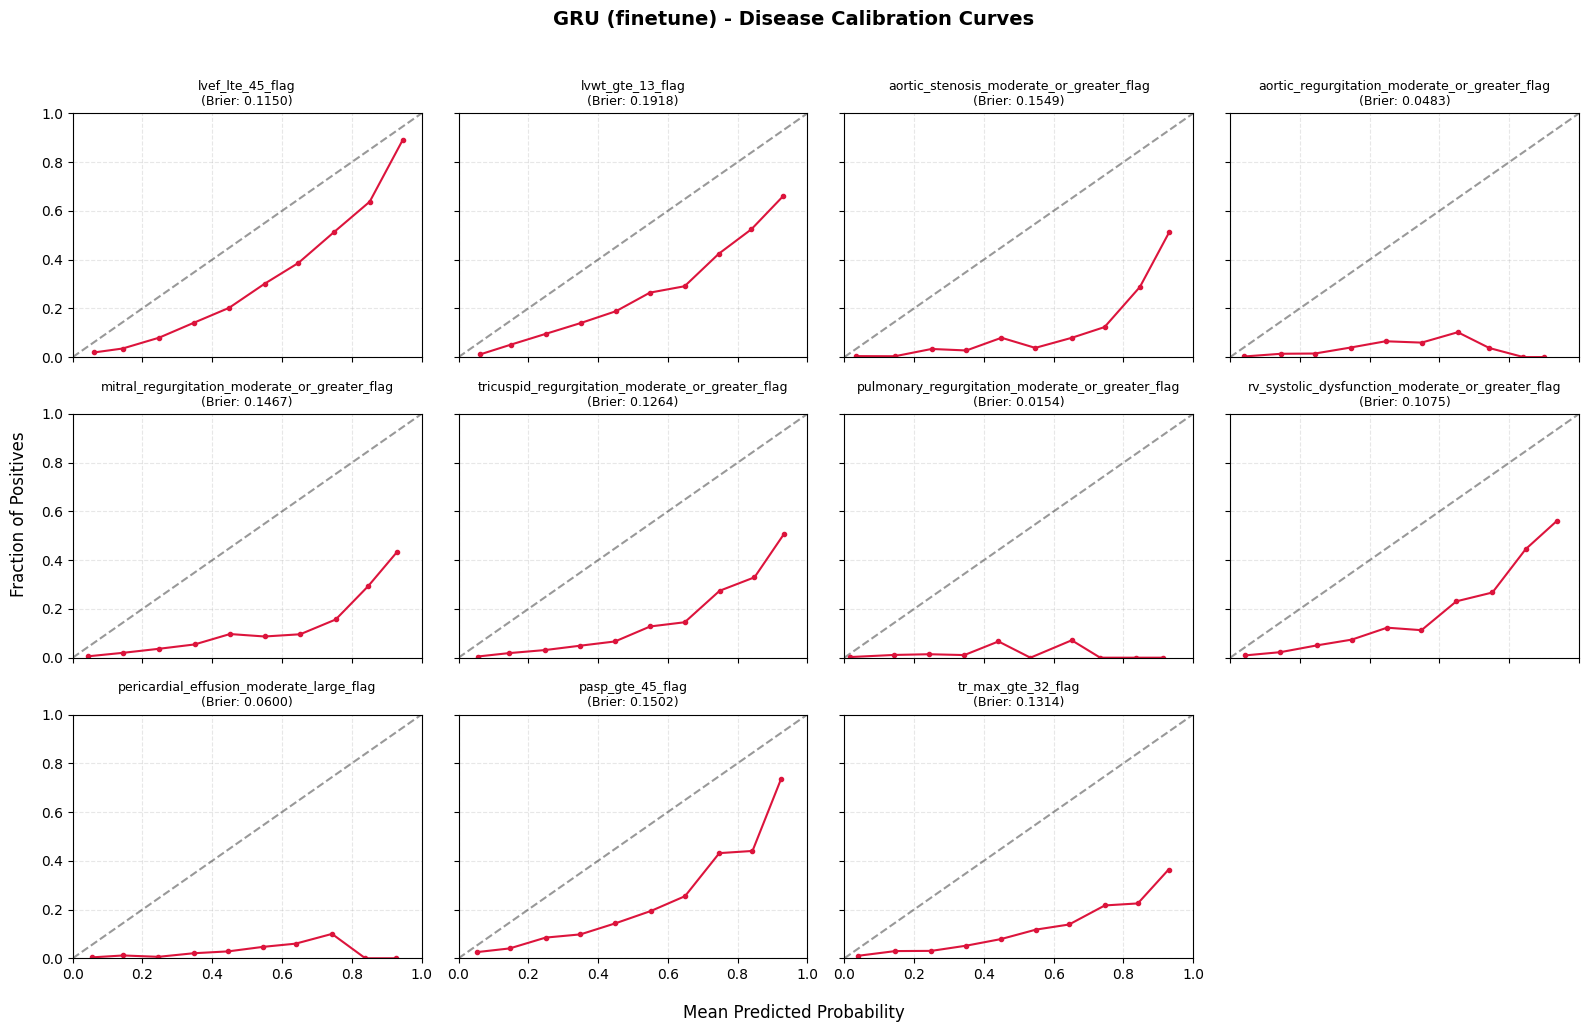

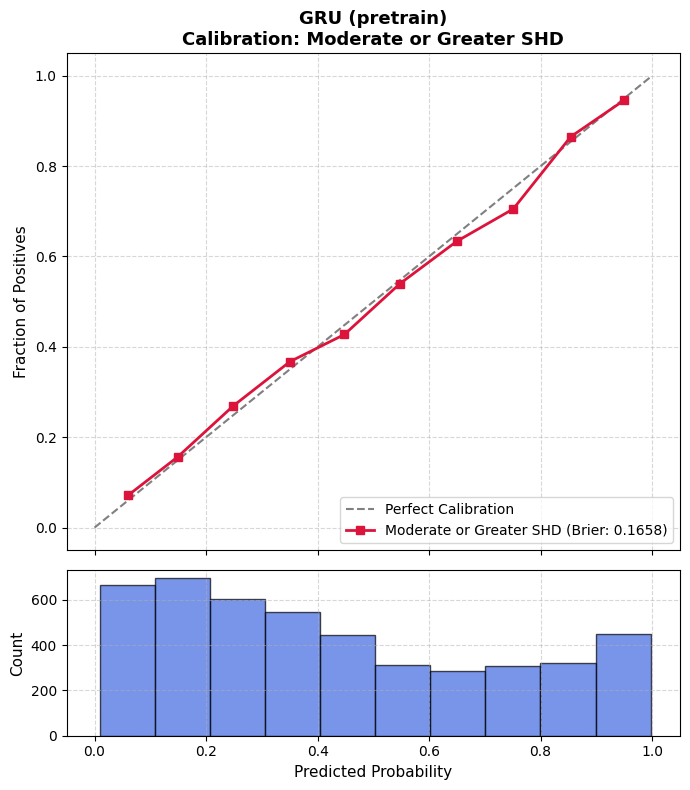

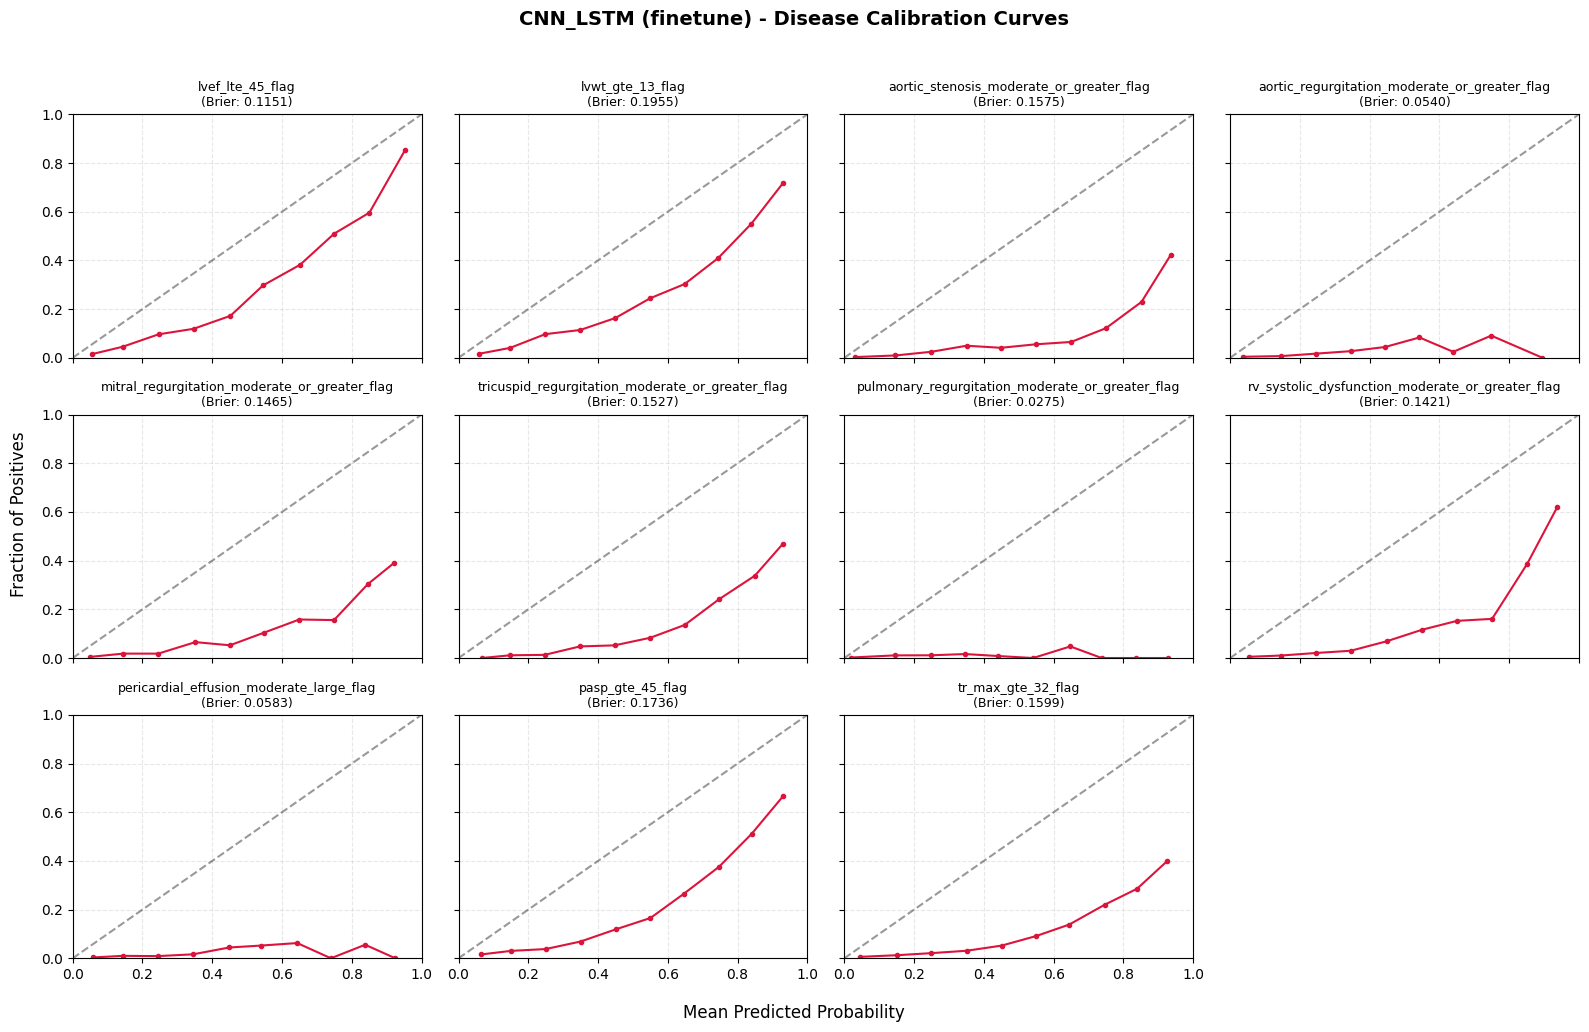

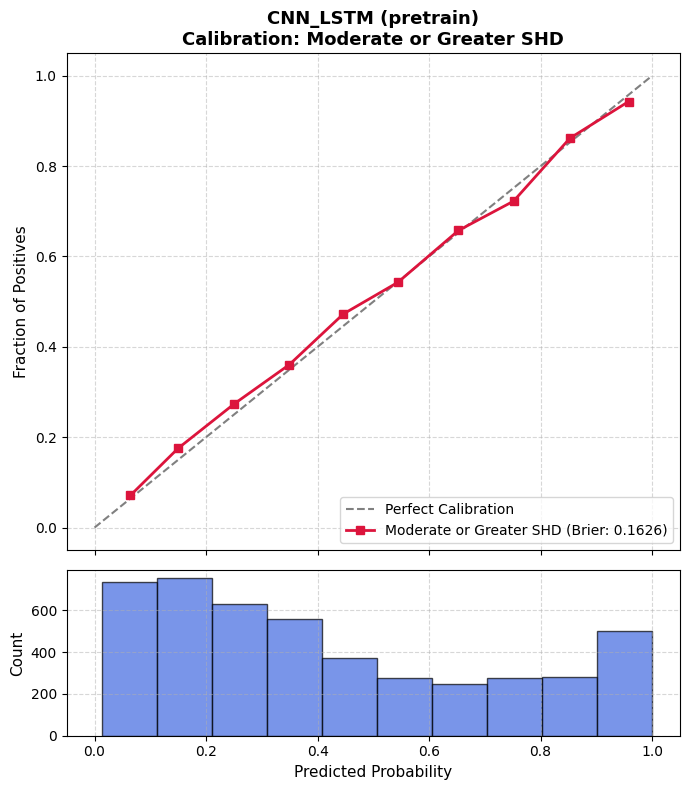

In [12]:
for i in range(len(val_logits_dict["model_type"])):
    if val_logits_dict["seed"][i] == SELECTED_SEED:
        model_type = val_logits_dict["model_type"][i]
        train_stage = val_logits_dict["train_stage"][i]
        logits = val_logits_dict["predictions"][i]

        model_name = f"{model_type.upper()} ({train_stage})"

        if train_stage == "pretrain":
            y_eval = val_y_true["shd_moderate_or_greater_flag"].to_numpy()
            
            brier_score = plot_logits_calibration(
                y_true=y_eval,
                logits=logits,
                labels="Moderate or Greater SHD",
                model_name=model_name
            )
        else:
            eval_df = val_y_true.drop(columns=["shd_moderate_or_greater_flag"])
            y_eval = eval_df.to_numpy()
            disease_labels = eval_df.columns.tolist()

            brier_score = plot_logits_calibration(
                y_true=y_eval,
                logits=logits,
                labels=disease_labels,
                model_name=model_name
            )

I decide not to calibrate the pretrained version, but only the finetuned one.

In [13]:
# calibrate finetuned models on validation set
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

def fit_multilabel_isotonic_scalers(val_logits, val_y_true):
    val_logits = np.asarray(val_logits)
    val_y_true = np.asarray(val_y_true)
    n_diseases = val_logits.shape[1]
    
    scalers = []
    for d in range(n_diseases):
        y_col = val_y_true[:, d]
        logit_col = val_logits[:, d]
        
        if len(np.unique(y_col)) > 1:
            iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip')
            iso.fit(logit_col, y_col)
            scalers.append(iso)
        else:
            scalers.append(None)
            
    return scalers

def transform_with_isotonic(logits, scalers):
    logits = np.asarray(logits)
    calibrated_probs = np.zeros_like(logits, dtype=float)
    
    for d, iso in enumerate(scalers):
        if iso is not None:
            calibrated_probs[:, d] = iso.predict(logits[:, d])
        else:
            # fallback to sigmoid if class was degenerate
            calibrated_probs[:, d] = 1.0 / (1.0 + np.exp(-np.clip(logits[:, d], -50, 50)))
            
    return calibrated_probs

In [14]:
eval_df = val_y_true.drop(columns=["shd_moderate_or_greater_flag"])
y_val_matrix = eval_df.to_numpy()
disease_names = eval_df.columns.tolist()

isotonic_artifacts = {}
seed_brier_summaries = []

for i in range(len(val_logits_dict["model_type"])):
    train_stage = val_logits_dict["train_stage"][i]
    
    if train_stage == "finetune":
        seed = val_logits_dict["seed"][i]
        model_type = val_logits_dict["model_type"][i]
        raw_logits = val_logits_dict["predictions"][i]
        
        raw_probs = 1.0 / (1.0 + np.exp(-np.clip(raw_logits, -50, 50)))
        
        scalers = fit_multilabel_isotonic_scalers(raw_logits, y_val_matrix)
        calibrated_probs = transform_with_isotonic(raw_logits, scalers)
        
        isotonic_artifacts[seed] = {
            "scalers": scalers,
            "calibrated_probs": calibrated_probs
        }
        
        for d_idx, d_name in enumerate(disease_names):
            if len(np.unique(y_val_matrix[:, d_idx])) > 1:
                b_raw = brier_score_loss(y_val_matrix[:, d_idx], raw_probs[:, d_idx])
                b_cal = brier_score_loss(y_val_matrix[:, d_idx], calibrated_probs[:, d_idx])
                
                seed_brier_summaries.append({
                    "Seed": seed,
                    "Model": model_type,
                    "Disease": d_name,
                    "Raw Brier": b_raw,
                    "Isotonic Brier": b_cal,
                    "Improvement (%)": ((b_raw - b_cal) / b_raw) * 100
                })

df_isotonic_results = pd.DataFrame(seed_brier_summaries)

In [15]:
summary_table = df_isotonic_results.groupby("Disease")[
    ["Raw Brier", "Isotonic Brier", "Improvement (%)"]
].agg(["mean", "std"]).round(4)

print(summary_table["Improvement (%)"])

                                                     mean     std
Disease                                                          
aortic_regurgitation_moderate_or_greater_flag     73.0888  3.8942
aortic_stenosis_moderate_or_greater_flag          71.7041  2.5571
lvef_lte_45_flag                                  23.4816  3.8012
lvwt_gte_13_flag                                  29.5420  3.7749
mitral_regurgitation_moderate_or_greater_flag     67.1208  2.2049
pasp_gte_45_flag                                  42.1357  3.0466
pericardial_effusion_moderate_large_flag          85.0512  2.0903
pulmonary_regurgitation_moderate_or_greater_flag  78.1154  3.5781
rv_systolic_dysfunction_moderate_or_greater_flag  52.7418  3.9993
tr_max_gte_32_flag                                67.7275  2.4703
tricuspid_regurgitation_moderate_or_greater_flag  62.8823  1.9940


In [16]:
def compute_clinical_metrics(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return {
        "Threshold": round(float(threshold), 3),
        "Accuracy": acc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "F1-Score": f1,
    }

def find_threshold_sens_70(y_true_list, probs_list, candidate_thresholds=None):
    if candidate_thresholds is None:
        candidate_thresholds = np.arange(0.05, 0.95, 0.05)

    stats = []
    for t in candidate_thresholds:
        recalls, precisions = [], []
        for y_true, probs in zip(y_true_list, probs_list):
            if len(np.unique(y_true)) <= 1:
                continue
            y_pred = (probs >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recalls.append(rec)
            precisions.append(prec)

        if len(recalls) > 0:
            stats.append({
                "threshold": t,
                "mean_recall": np.mean(recalls),
                "mean_precision": np.mean(precisions),
            })

    if not stats:
        return 0.5

    df_stats = pd.DataFrame(stats)
    high_rec = df_stats[df_stats["mean_recall"] >= 0.70]

    if len(high_rec) > 0:
        # highest precision with lowest recall among points with sens >= 0.70 like in echonext mini paper
        best_row = high_rec.sort_values(
            by=["mean_precision", "mean_recall"], ascending=[False, True]
        ).iloc[0]
    else:
        # fallback to threshold maximizing sensitivity
        best_row = df_stats.sort_values(
            by=["mean_recall", "mean_precision"], ascending=[False, False]
        ).iloc[0]

    return round(float(best_row["threshold"]), 2)

y_val_composite = val_y_true["shd_moderate_or_greater_flag"].to_numpy()
eval_df_val = val_y_true.drop(columns=["shd_moderate_or_greater_flag"])
y_val_diseases = eval_df_val.to_numpy()
disease_names = eval_df_val.columns.tolist()

val_grouped = {}
for i in range(len(val_logits_dict["model_type"])):
    stage = val_logits_dict["train_stage"][i]
    m_type = val_logits_dict["model_type"][i]
    seed = val_logits_dict["seed"][i]
    raw_l = val_logits_dict["predictions"][i]

    key = (stage, m_type)
    if key not in val_grouped:
        val_grouped[key] = []

    if stage == "pretrain":
        p = 1.0 / (1.0 + np.exp(-np.clip(raw_l.squeeze(), -50, 50)))
        val_grouped[key].append((y_val_composite, p))
    elif stage == "finetune":
        lookup_key = (m_type, seed) if (m_type, seed) in isotonic_artifacts else seed
        scalers = isotonic_artifacts[lookup_key]["scalers"]
        cal_p = transform_with_isotonic(raw_l, scalers)
        val_grouped[key].append((y_val_diseases, cal_p))

threshold_lookup_70 = {}

for (stage, m_type), data_pairs in val_grouped.items():
    if stage == "pretrain":
        y_list = [pair[0] for pair in data_pairs]
        p_list = [pair[1] for pair in data_pairs]
        t_opt = find_threshold_sens_70(y_list, p_list)
        threshold_lookup_70[(stage, m_type, "Moderate or Greater SHD")] = t_opt

    elif stage == "finetune":
        for d_idx, d_name in enumerate(disease_names):
            y_list = [pair[0][:, d_idx] for pair in data_pairs]
            p_list = [pair[1][:, d_idx] for pair in data_pairs]
            t_opt = find_threshold_sens_70(y_list, p_list)
            threshold_lookup_70[(stage, m_type, d_name)] = t_opt


test_y_composite = test_y_true["shd_moderate_or_greater_flag"].to_numpy()
eval_df_test = test_y_true.drop(columns=["shd_moderate_or_greater_flag"])
test_y_diseases = eval_df_test.to_numpy()

all_clinical_records = []

for i in range(len(test_logits_dict["model_type"])):
    stage = test_logits_dict["train_stage"][i]
    m_type = test_logits_dict["model_type"][i]
    seed = test_logits_dict["seed"][i]
    raw_logits = test_logits_dict["predictions"][i]

    if stage == "pretrain":
        p_col = 1.0 / (1.0 + np.exp(-np.clip(raw_logits.squeeze(), -50, 50)))
        y_col = test_y_composite.squeeze()

        t_val = threshold_lookup_70.get((stage, m_type, "Moderate or Greater SHD"), 0.5)
        metrics = compute_clinical_metrics(y_col, p_col, t_val)

        all_clinical_records.append({
            "Train Stage": stage,
            "Model Type": m_type,
            "Seed": seed,
            "Target": "Moderate or Greater SHD",
            "AUROC": roc_auc_score(y_col, p_col) if len(np.unique(y_col)) > 1 else np.nan,
            "AUPRC": average_precision_score(y_col, p_col) if len(np.unique(y_col)) > 1 else np.nan,
            **metrics
        })

    elif stage == "finetune":
        lookup_key = (m_type, seed) if (m_type, seed) in isotonic_artifacts else seed
        scalers = isotonic_artifacts[lookup_key]["scalers"]
        calibrated_probs = transform_with_isotonic(raw_logits, scalers)

        for d_idx, d_name in enumerate(disease_names):
            y_col = test_y_diseases[:, d_idx]
            p_col = calibrated_probs[:, d_idx]

            t_val = threshold_lookup_70.get((stage, m_type, d_name), 0.5)
            metrics = compute_clinical_metrics(y_col, p_col, t_val)

            all_clinical_records.append({
                "Train Stage": stage,
                "Model Type": m_type,
                "Seed": seed,
                "Target": d_name,
                "AUROC": roc_auc_score(y_col, p_col) if len(np.unique(y_col)) > 1 else np.nan,
                "AUPRC": average_precision_score(y_col, p_col) if len(np.unique(y_col)) > 1 else np.nan,
                **metrics
            })

df_clinical_test = pd.DataFrame(all_clinical_records)
eval_cols = ["AUROC", "AUPRC", "Threshold", "Sensitivity", "Specificity", "PPV", "NPV", "Accuracy", "F1-Score"]

agg_summary = (
    df_clinical_test
    .groupby(["Train Stage", "Model Type", "Target"])[eval_cols]
    .agg(["mean", "std"])
)

formatted_df = pd.DataFrame(index=agg_summary.index)
for col in eval_cols:
    if col == "Threshold":
        formatted_df[col] = agg_summary[col]["mean"].apply(lambda v: f"{v:.3f}")
    else:
        formatted_df[col] = agg_summary[col].apply(
            lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}" if pd.notnull(r['std']) else f"{r['mean']:.4f}",
            axis=1
        )

final_table = formatted_df.reset_index()

df_finetune = final_table[final_table["Train Stage"] == "finetune"].drop(columns=["Train Stage"])
df_pretrain = final_table[final_table["Train Stage"] == "pretrain"].drop(columns=["Train Stage"])

print("=" * 135)
print("FINETUNED (ISOTONIC CALIBRATED) TEST SET METRICS (OPERATING POINT: SENSITIVITY >= 0.70)")
print("=" * 135)
print(df_finetune.to_string(index=False))

print("\n" + "=" * 135)
print("PRETRAINED TEST SET METRICS (OPERATING POINT: SENSITIVITY >= 0.70)")
print("=" * 135)
print(df_pretrain.to_string(index=False))

FINETUNED (ISOTONIC CALIBRATED) TEST SET METRICS (OPERATING POINT: SENSITIVITY >= 0.70)
Model Type                                           Target           AUROC           AUPRC Threshold     Sensitivity     Specificity             PPV             NPV        Accuracy        F1-Score
  cnn_lstm    aortic_regurgitation_moderate_or_greater_flag 0.7601 ± 0.0120 0.0336 ± 0.0026     0.050 0.1939 ± 0.0790 0.9474 ± 0.0158 0.0430 ± 0.0114 0.9897 ± 0.0009 0.9382 ± 0.0148 0.0695 ± 0.0185
  cnn_lstm         aortic_stenosis_moderate_or_greater_flag 0.8754 ± 0.0026 0.2932 ± 0.0065     0.050 0.8413 ± 0.0798 0.7388 ± 0.0630 0.1557 ± 0.0234 0.9885 ± 0.0045 0.7442 ± 0.0557 0.2610 ± 0.0275
  cnn_lstm                                 lvef_lte_45_flag 0.8855 ± 0.0024 0.6698 ± 0.0053     0.300 0.6909 ± 0.0209 0.8955 ± 0.0125 0.5880 ± 0.0221 0.9310 ± 0.0034 0.8594 ± 0.0067 0.6347 ± 0.0042
  cnn_lstm                                 lvwt_gte_13_flag 0.7665 ± 0.0018 0.4197 ± 0.0046     0.200 0.7110 ± 0.0341 0.

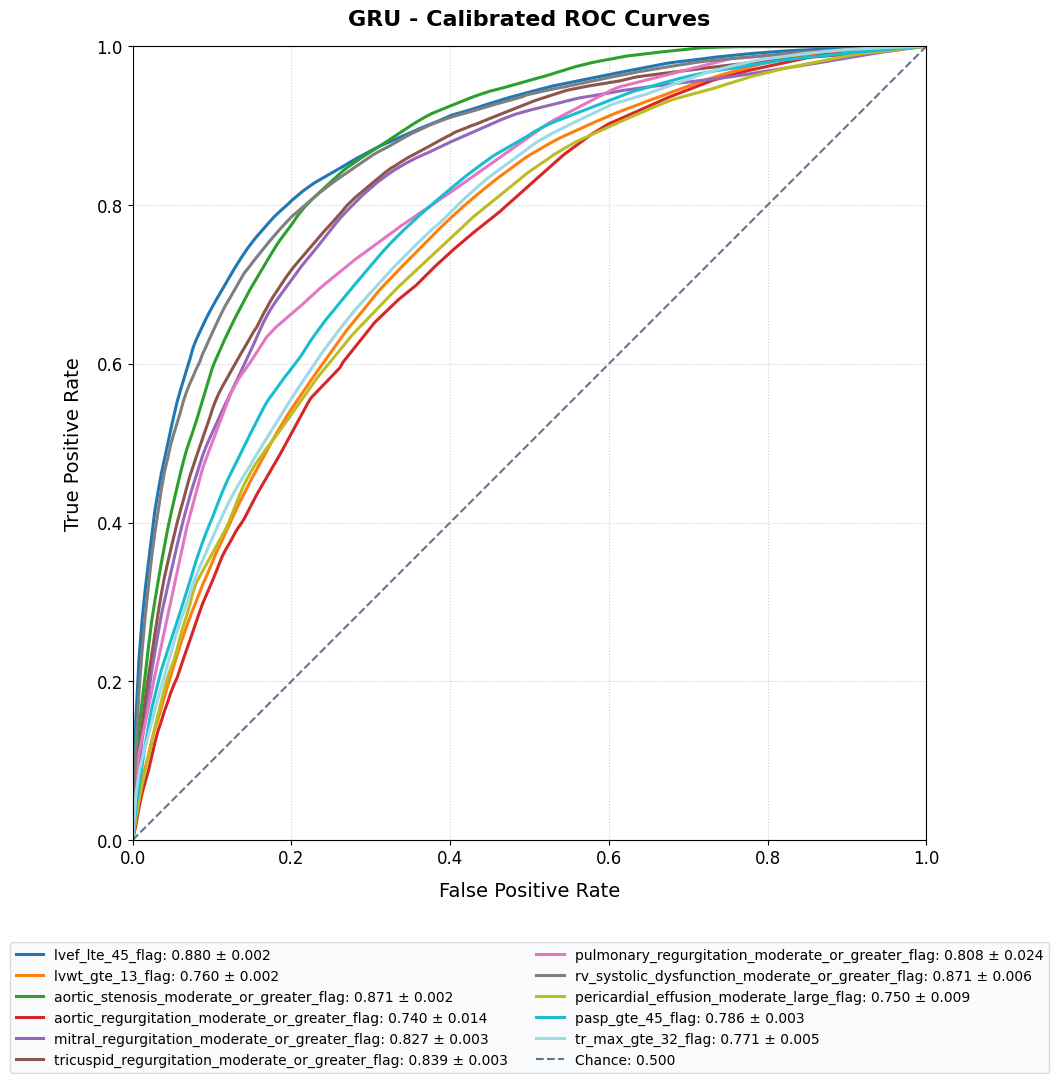

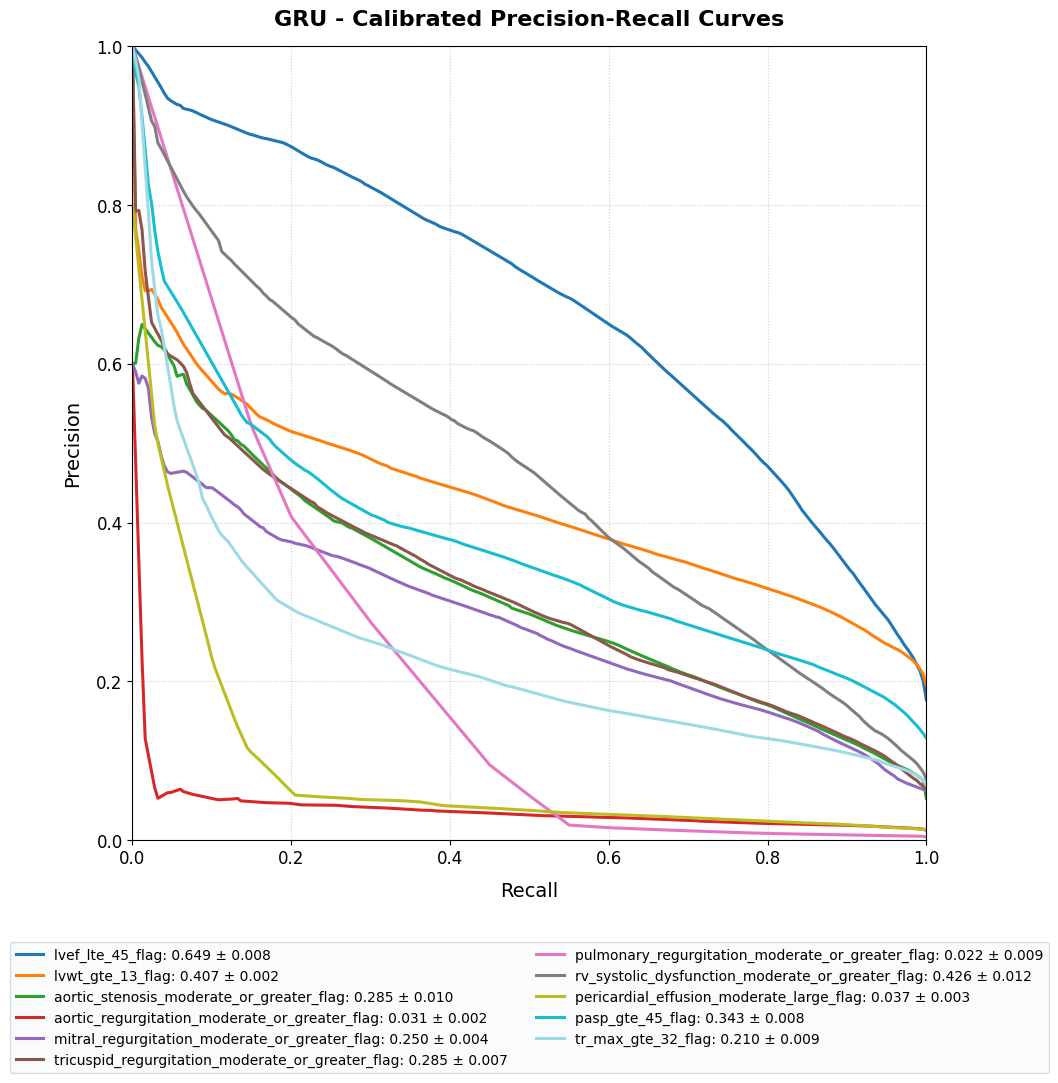

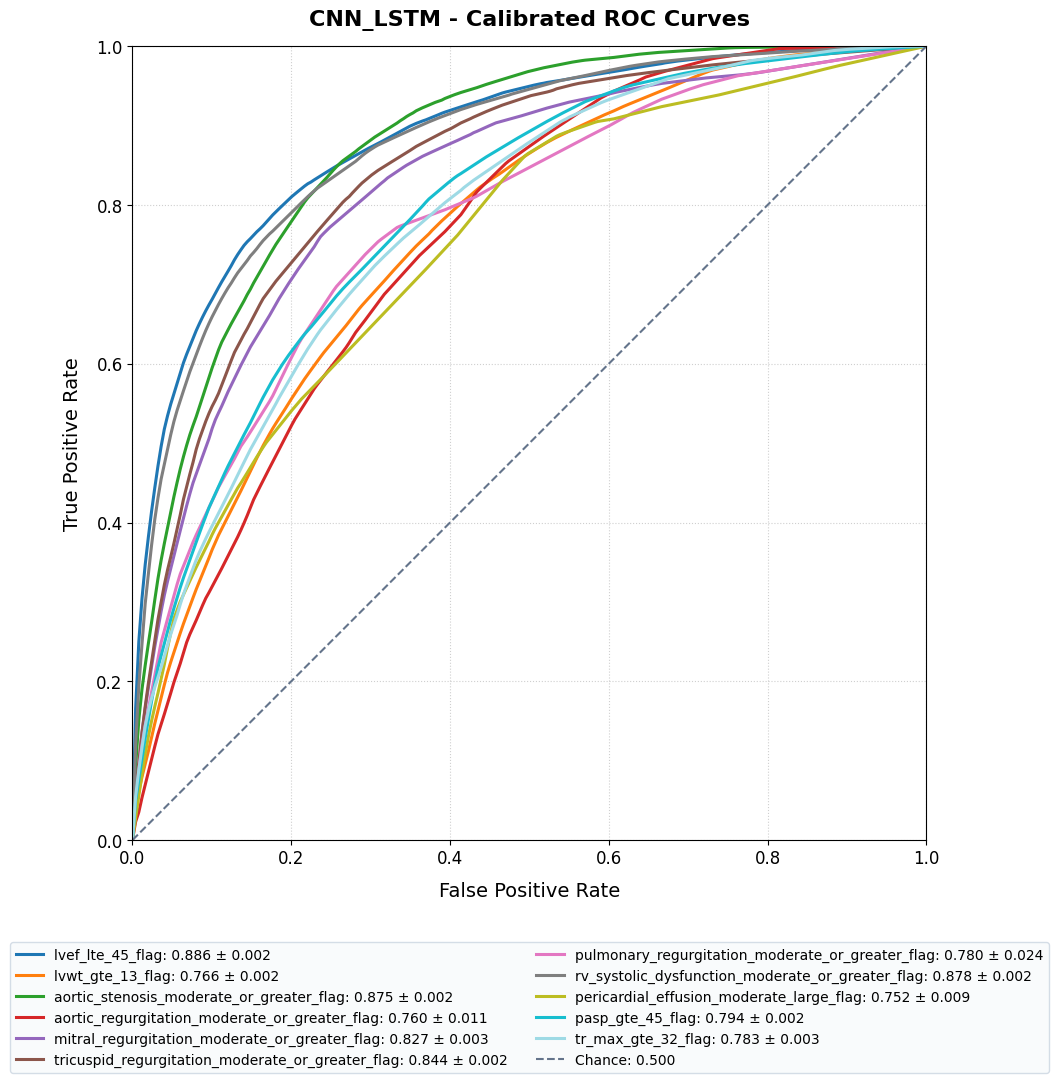

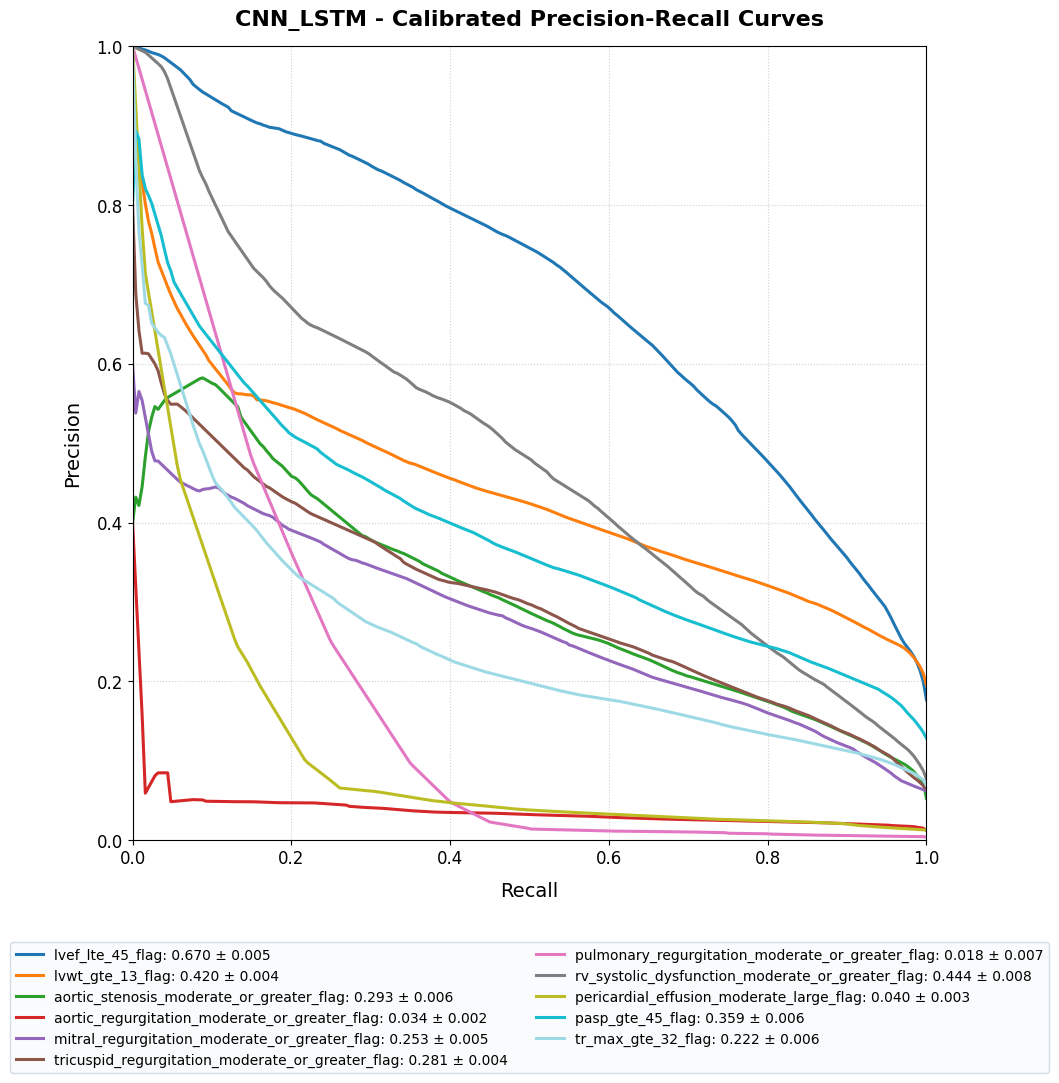

In [17]:
eval_df_test = test_y_true.drop(columns=["shd_moderate_or_greater_flag"])
test_y_diseases = eval_df_test.to_numpy()
disease_names = eval_df_test.columns.tolist()

finetune_test_probs = {}

for i in range(len(test_logits_dict["model_type"])):
    stage = test_logits_dict["train_stage"][i]
    if stage != "finetune":
        continue

    m_type = test_logits_dict["model_type"][i]
    seed = test_logits_dict["seed"][i]
    raw_logits = test_logits_dict["predictions"][i]

    lookup_key = (m_type, seed) if (m_type, seed) in isotonic_artifacts else seed
    scalers = isotonic_artifacts[lookup_key]["scalers"]
    calibrated_probs = transform_with_isotonic(raw_logits, scalers)

    if m_type not in finetune_test_probs:
        finetune_test_probs[m_type] = []
    finetune_test_probs[m_type].append(calibrated_probs)

colors = plt.cm.tab20(np.linspace(0, 1, len(disease_names)))

for m_type, seed_probs in finetune_test_probs.items():
    fig_roc, ax_roc = plt.subplots(figsize=(11, 11))
    mean_fpr = np.linspace(0, 1, 250)

    for d_idx, d_name in enumerate(disease_names):
        y_col = test_y_diseases[:, d_idx]
        if len(np.unique(y_col)) <= 1:
            continue

        tprs = []
        aurocs = []
        for p in seed_probs:
            fpr, tpr, _ = roc_curve(y_col, p[:, d_idx])
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)
            aurocs.append(auc(fpr, tpr))

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        ax_roc.plot(
            mean_fpr, mean_tpr, lw=2.2, color=colors[d_idx],
            label=f"{d_name}: {np.mean(aurocs):.3f} ± {np.std(aurocs):.3f}"
        )

    ax_roc.plot([0, 1], [0, 1], linestyle="--", color="#64748b", lw=1.5, label="Chance: 0.500")
    ax_roc.set_aspect("equal", adjustable="box")
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.0])
    ax_roc.tick_params(axis="both", labelsize=12)
    ax_roc.set_title(f"{m_type.upper()} - Calibrated ROC Curves", fontsize=16, fontweight="bold", pad=15)
    ax_roc.set_xlabel("False Positive Rate", fontsize=14, labelpad=10)
    ax_roc.set_ylabel("True Positive Rate", fontsize=14, labelpad=10)
    ax_roc.grid(True, linestyle=":", alpha=0.6)

    ax_roc.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=2,
        fontsize=10,
        frameon=True,
        facecolor="#f8fafc",
        edgecolor="#cbd5e1"
    )
    plt.tight_layout()
    plt.show()

    fig_pr, ax_pr = plt.subplots(figsize=(11, 11))
    mean_recall = np.linspace(0, 1, 250)

    for d_idx, d_name in enumerate(disease_names):
        y_col = test_y_diseases[:, d_idx]
        if len(np.unique(y_col)) <= 1:
            continue

        precisions = []
        auprcs = []
        for p in seed_probs:
            prec, rec, _ = precision_recall_curve(y_col, p[:, d_idx])
            interp_prec = np.interp(mean_recall, rec[::-1], prec[::-1])
            precisions.append(interp_prec)
            auprcs.append(average_precision_score(y_col, p[:, d_idx]))

        mean_prec = np.mean(precisions, axis=0)
        ax_pr.plot(
            mean_recall, mean_prec, lw=2.2, color=colors[d_idx],
            label=f"{d_name}: {np.mean(auprcs):.3f} ± {np.std(auprcs):.3f}"
        )

    ax_pr.set_aspect("equal", adjustable="box")
    ax_pr.set_xlim([0.0, 1.0])
    ax_pr.set_ylim([0.0, 1.0])
    ax_pr.tick_params(axis="both", labelsize=12)
    ax_pr.set_title(f"{m_type.upper()} - Calibrated Precision-Recall Curves", fontsize=16, fontweight="bold", pad=15)
    ax_pr.set_xlabel("Recall", fontsize=14, labelpad=10)
    ax_pr.set_ylabel("Precision", fontsize=14, labelpad=10)
    ax_pr.grid(True, linestyle=":", alpha=0.6)

    ax_pr.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=2,
        fontsize=10,
        frameon=True,
        facecolor="#f8fafc",
        edgecolor="#cbd5e1"
    )
    plt.tight_layout()
    plt.show()